In [151]:
import numpy as np
import pandas as pd

import tensorflow as tf

In [152]:
df = pd.read_csv('AAMC.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-12-13,15.0,15.0,15.0,15.0,15.0,100
1,2012-12-14,19.0,30.0,19.0,30.0,30.0,144600
2,2012-12-17,31.5,65.0,31.5,65.0,65.0,68600
3,2012-12-18,65.0,89.0,65.0,80.0,80.0,43600
4,2012-12-19,80.0,84.0,78.0,84.0,84.0,24000


In [153]:
data = df['Close'].to_numpy().reshape(-1, 1)

In [154]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

data = scaler.fit_transform(data)

In [155]:
def create(data, time):
    X, y = [], []

    for i in range(time, len(data)):
        X.append(data[i-time:i, 0])
        y.append(data[i, 0])
    
    return np.array(X), np.array(y)

In [160]:
X, y = create(data, 60)

In [161]:
X.shape

(1777, 60)

In [162]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [163]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [164]:
model = Sequential([
    LSTM(40, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(40),
    Dense(1)
])

/Users/aryanahuja/Documents/Aryan/Projects/DL_Prac/env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [165]:
model.compile(optimizer="adam", loss="mean_squared_error")

In [166]:
history = model.fit(X_train, y_train, epochs=10)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0125
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0020
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0016
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013
Epoch 9/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012
Epoch 10/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.9618e-04


In [167]:
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


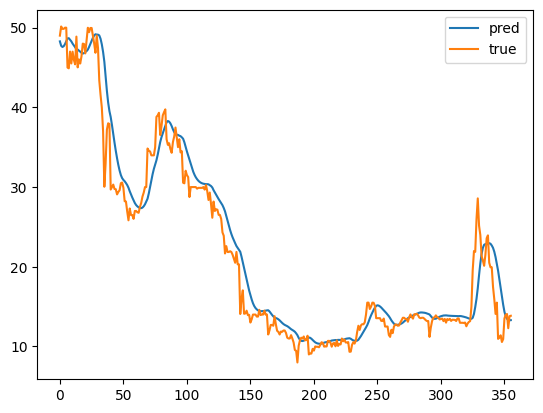

In [168]:
import matplotlib.pyplot as plt

plt.plot(y_pred, label="pred")
plt.plot(y_test, label="true")
plt.legend()